# Purpose:
- Too many neurons show reduced coding score on novelty.
    - Look at population mean responses to images and omissions
- Validate coding score


In [1]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
import glm_fit_tools as gft
import design_matrix_tools as dmtools
import kernel_tools as ktools
import load_data
import vba_tools

from sklearn.cluster import SpectralClustering

import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json

from matplotlib import pyplot as plt
import seaborn as sns

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils



In [2]:
data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('stim-response' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'

session_names = [rp.split('/')[-1] for rp in raw_paths]
session_keys = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'session_key': session_keys,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('session_key', drop=True, inplace=True)
session_info_df

,session_name,session_ind,session_type
session_key,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [3]:
session_ind_name_dict = {6: 'Familiar',
                         7: 'Novel',
                         8: 'Novel+1'}

In [4]:
roicat_df_fn = '/root/capsule/scratch/Thyme/roicat_df.pkl'
roicat_df = pd.read_pickle(roicat_df_fn)
f1n2_session_inds = [6, 7, 8]
f1n2_roi_df = roicat_df.query('valid_roi and (session_ind in @f1n2_session_inds) and matched')
f1n2_uc_series = f1n2_roi_df.groupby('unique_cell_name').size()
f1n2_matched_uc = f1n2_uc_series.index.values[np.where(f1n2_uc_series==len(f1n2_session_inds))[0]]
print(len(f1n2_matched_uc))
f1n2_all_matched_roi_df = f1n2_roi_df.query('unique_cell_name in @f1n2_matched_uc')
f1n2_all_matched_roi_df.head()

291


,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key_x,session_ind,unique_cell_name,cell_roi_id,valid_roi,exclusion_labels,touching_motion_border,small_roi,session_key_y,plane_session_key,session_key
roi_name,,,,,,,,,,,,,,,,,,,,
736963_2024-08-09_VISp_0_0005,5,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,5,88,db55ec77-70e9-4e64-8e7f-caa9660a4d5e,0.992339,0.976572,True,736963_2024-08-09,8,VISp_0_0088,5,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0007,7,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,7,101,f2aabcb6-bfb4-40ee-9ea1-e7f420475ab5,0.902556,1.000000,True,736963_2024-08-09,8,VISp_0_0101,7,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0008,8,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,8,98,fb45dc23-e4d5-4ebf-a5a9-b0c3c4eb36ff,0.982731,1.000000,True,736963_2024-08-09,8,VISp_0_0098,8,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0009,9,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,9,99,8483a820-9d1f-4576-ae40-7b868e611d9e,0.917262,1.000000,True,736963_2024-08-09,8,VISp_0_0099,9,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0010,10,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,10,3,127fcf28-5de9-480a-8218-3a5850abeaf5,0.985113,0.968638,True,736963_2024-08-09,8,VISp_0_0003,10,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09


# Mean responses

In [13]:
mean_response_path = Path('/root/capsule/data/single_cell_mean_responses_736963_natural_images_condition_v0')
mean_response_df = pd.DataFrame()
for session_ind in session_ind_name_dict.keys():
    session_name = session_info_df.query(f'session_ind=={session_ind}').session_name.values[0]
    mean_response_fn = mean_response_path / f'response_v0_{session_name}.feather'
    temp_response_df = pd.read_feather(mean_response_fn)
    conditions = temp_response_df.condition.unique()
    image_condition = [condition for condition in conditions if 'image' in condition][0]
    temp_response_df.loc[temp_response_df.condition==image_condition, 'condition'] = 'all-images'
    temp_response_df['session_ind'] = session_ind
    temp_response_df['experience_level'] = session_ind_name_dict[session_ind]
    mean_response_df = pd.concat([mean_response_df, temp_response_df])
    

In [22]:
[len(ts) for ts in mean_response_df.groupby('session_ind').timestamps.mean().values]

[65, 65, 65]

In [31]:
timestamps_sessions = [ts.round(2) for ts in mean_response_df.groupby('session_ind').timestamps.mean().values]
[ts==timestamps_sessions[0] for ts in timestamps_sessions]

[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True]),
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True, Fal

In [39]:
common_timestamps = timestamps_sessions[0]

### There's a little mis-alignment but I can live with it for now
- No need for interpolation

In [35]:
mean_response_df

,response_from_baseline,p_value,data_type,condition,mean_trace,std_trace,timestamps,plane_name,session_key,session_ind,experience_level
cell_roi_id,,,,,,,,,,,
9,0.044404,7.536359e-19,dff,all-images,"[0.020088494550442922, 0.037798915663918915, 0...","[0.4628336907425982, 0.3864339169296799, 0.385...","[-3.0, -2.9069172870779783, -2.813834574155957...",VISp_7,736963_2024-08-06,6,Familiar
10,0.013649,5.418056e-13,dff,all-images,"[0.038839818247084885, 0.04776294181291223, 0....","[0.198009065076792, 0.1880223299114979, 0.2017...","[-3.0, -2.9069172870779783, -2.813834574155957...",VISp_7,736963_2024-08-06,6,Familiar
11,0.040413,1.598843e-08,dff,all-images,"[0.04916525567116025, 0.07089157531320413, 0.0...","[0.6435029995241294, 0.5405038609255096, 0.553...","[-3.0, -2.9069172870779783, -2.813834574155957...",VISp_7,736963_2024-08-06,6,Familiar
12,-0.010131,2.867715e-06,dff,all-images,"[0.22569333077750106, 0.22558227234484202, 0.1...","[0.39176138845559144, 0.3794738994676509, 0.36...","[-3.0, -2.9069172870779783, -2.813834574155957...",VISp_7,736963_2024-08-06,6,Familiar
13,0.004961,9.877683e-03,dff,all-images,"[0.024086466240193793, 0.028580425109534024, 0...","[0.20134049866890474, 0.1836317318422251, 0.18...","[-3.0, -2.9069172870779783, -2.813834574155957...",VISp_7,736963_2024-08-06,6,Familiar
...,...,...,...,...,...,...,...,...,...,...,...
46,0.002142,1.714846e-04,events,omitted,"[0.006345853443828322, 0.016553445847190065, 0...","[0.021725489802006195, 0.03151163124492529, 0....","[-3.0, -2.9069116949608156, -2.813823389921631...",VISp_6,736963_2024-08-09,8,Novel+1
47,0.005979,6.625037e-02,events,omitted,"[0.0017461309990575236, 0.0038257194863707327,...","[0.010912823835597971, 0.022427214898700885, 0...","[-3.0, -2.9069116949608156, -2.813823389921631...",VISp_6,736963_2024-08-09,8,Novel+1
48,-0.004971,3.524623e-01,events,omitted,"[0.01207553151874773, 0.009689317338015643, 0....","[0.050958278543558305, 0.032247476662869035, 0...","[-3.0, -2.9069116949608156, -2.813823389921631...",VISp_6,736963_2024-08-09,8,Novel+1


In [38]:
mean_response_df.query('condition=="all-images" and data_type=="dff"').groupby('session_ind')[['mean_trace']].mean()

,mean_trace
session_ind,
6,"[0.08653271247524123, 0.09685976660379501, 0.1..."
7,"[0.05947952408661385, 0.08281643014452944, 0.1..."
8,"[0.07271746095641093, 0.08978634938397854, 0.1..."


,std_trace
session_ind,
6,"[0.00015281246765161389, 0.0001406102998276208..."
7,"[0.00017510643373780898, 0.0001604225955085673..."
8,"[0.00016009379195681384, 0.0001475337732459996..."


In [57]:
mean_image_responses.iloc[si].values[0]

array([0.08653271, 0.09685977, 0.10266525, 0.12155794, 0.10543119,
       0.08414413, 0.0940468 , 0.08424893, 0.07918031, 0.09568224,
       0.10198955, 0.12022096, 0.1079035 , 0.08405089, 0.09389814,
       0.08499717, 0.0787668 , 0.09472909, 0.10196726, 0.11921756,
       0.11050343, 0.08434341, 0.0936652 , 0.08583855, 0.07847655,
       0.09336093, 0.10182671, 0.11785262, 0.11278365, 0.0845132 ,
       0.09319445, 0.08680444, 0.07844914, 0.09280451, 0.10244678,
       0.11724533, 0.11594103, 0.08471447, 0.09207376, 0.08653275,
       0.07646023, 0.08833025, 0.09860555, 0.11169497, 0.1144557 ,
       0.08364486, 0.09025402, 0.08716985, 0.0771045 , 0.08821386,
       0.10027382, 0.11224402, 0.11804918, 0.08614306, 0.09071972,
       0.08890893, 0.07811728, 0.08745466, 0.10055433, 0.11105703,
       0.11995757, 0.08756713, 0.08988347, 0.08972046, 0.07879277])

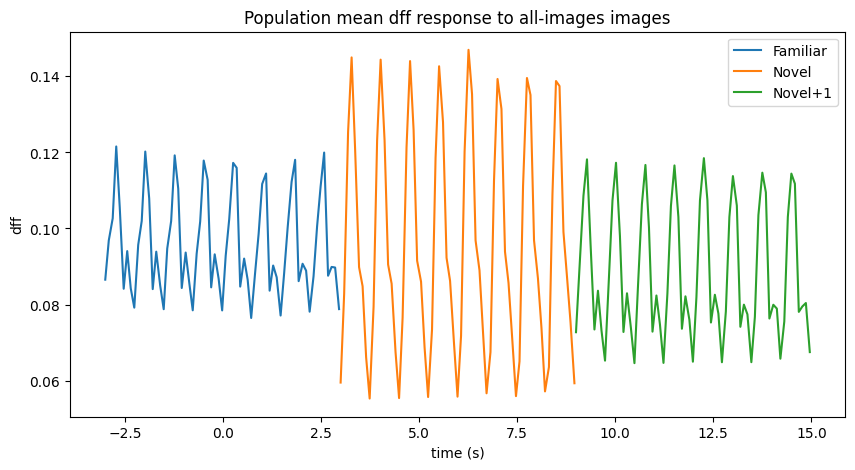

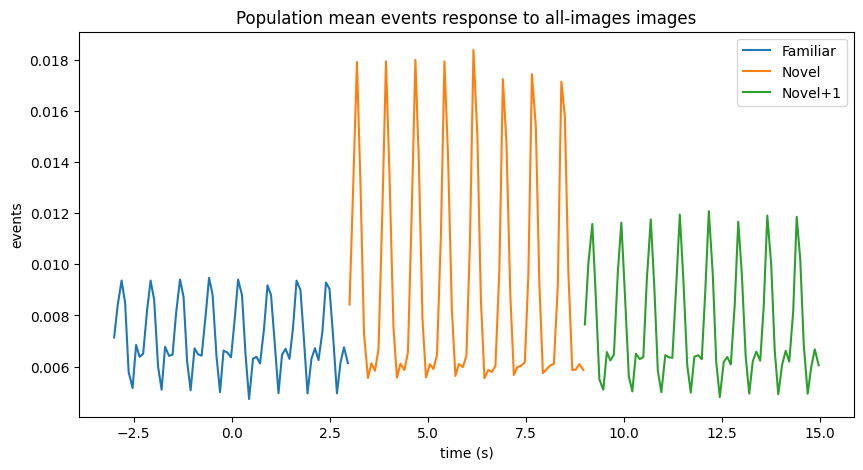

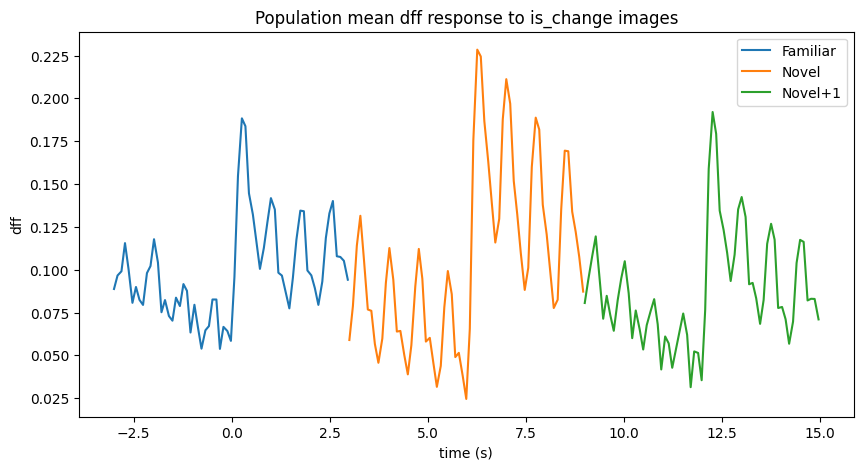

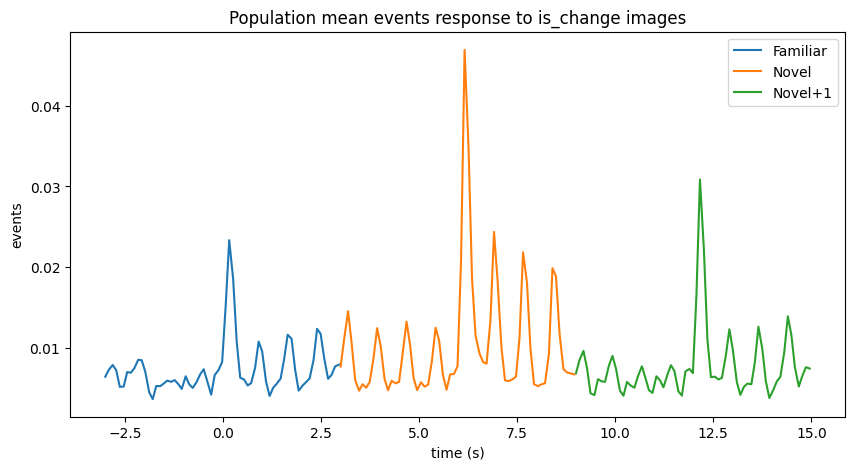

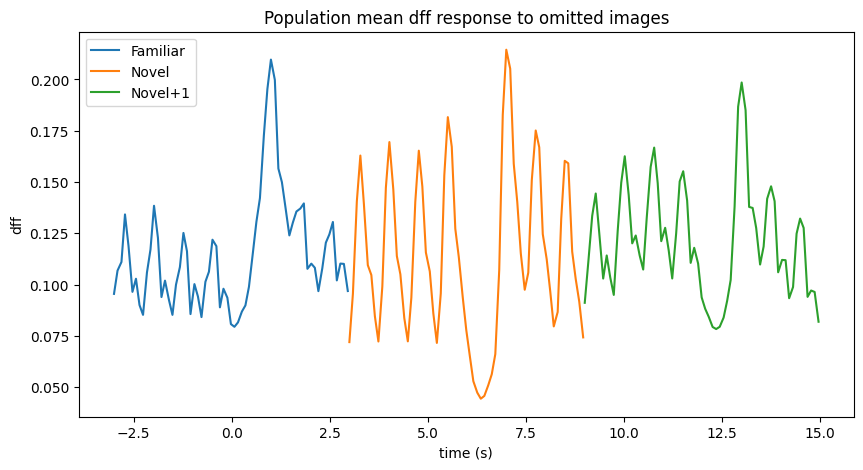

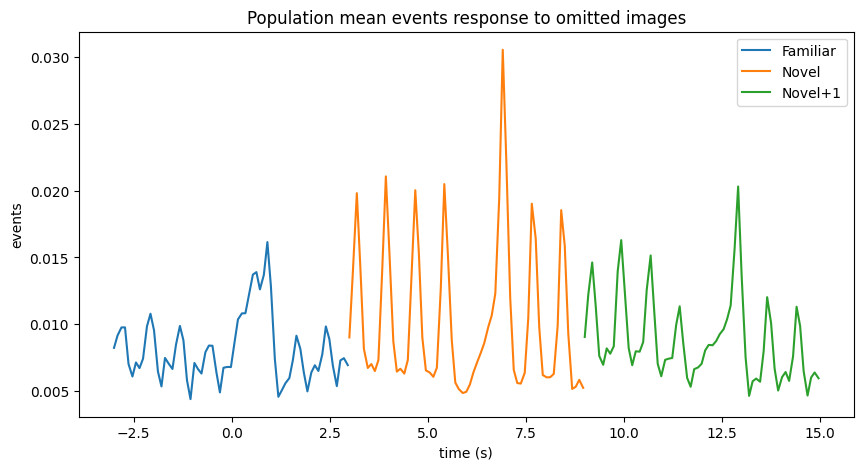

In [64]:
conditions = mean_response_df.condition.unique()
data_types = mean_response_df.data_type.unique()
for condition in conditions:
    for data_type in data_types:
        mean_responses = mean_response_df.query(f'condition=="{condition}" and data_type=="{data_type}"').groupby('session_ind')[['mean_trace']].mean()
        sem_responses = pd.DataFrame(mean_response_df.query(f'condition=="{condition}" and data_type=="{data_type}"').groupby(
            'session_ind')[['mean_trace']].apply(
                lambda x: np.std(x.values)/x.values.shape[0]))
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))        
        for si in range(3):
            x = common_timestamps + si * 6
            mean = mean_responses.iloc[si].values[0]
            sem = sem_responses.iloc[si].values[0]
            ax.fill_between(x, mean - sem, mean + sem, alpha=0.5)
            ax.plot(x, mean, label=session_ind_name_dict[list(session_ind_name_dict.keys())[si]])
        ax.legend()
        ax.set_xlabel('time (s)')
        ax.set_ylabel(data_type)
        ax.set_title(f'Population mean {data_type} response to {condition} images')


In [ ]:
mean_image_responses = mean_response_df.query('condition=="all-images" and data_type=="dff"').groupby('session_ind')[['mean_trace']].mean()
sem_image_responses = pd.DataFrame(mean_response_df.query('condition=="all-images" and data_type=="dff"').groupby(
    'session_ind')[['mean_trace']].apply(
        lambda x: np.std(x.values)/x.values.shape[0])).rename(
            columns={'mean_trace': 'sem_trace'})
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for si in range(3):
    x = common_timestamps + si * 6
    mean = mean_image_responses.iloc[si].values[0]
    sem = sem_image_responses.iloc[si].values[0]
    ax.fill_between(x, mean - sem, mean + sem, alpha=0.5)
    ax.plot(x, mean, label=session_ind_name_dict[list(session_ind_name_dict.keys())[si]])
ax.legend()
ax.set_xlabel('time (s)')
ax.set_ylabel('DFF')
ax.set_title('Mean DFF response to all images')

Text(0.5, 1.0, 'Mean DFF response to changes')

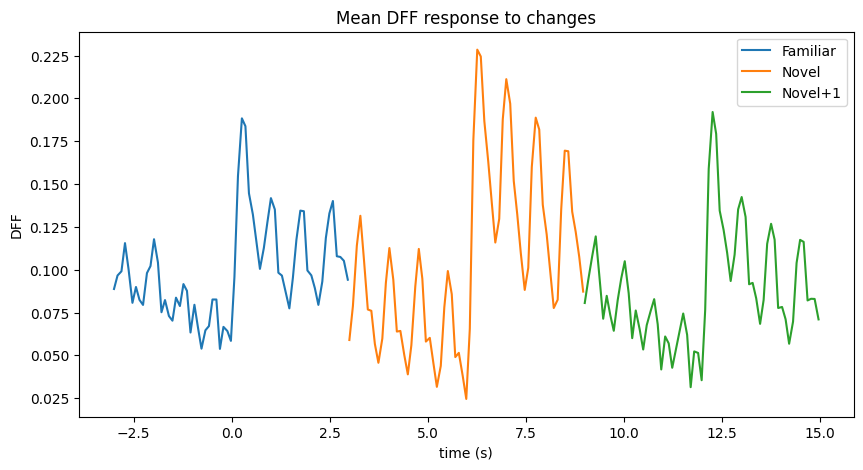

In [62]:
mean_change_responses = mean_response_df.query('condition=="is_change" and data_type=="dff"').groupby('session_ind')[['mean_trace']].mean()
sem_change_responses = pd.DataFrame(mean_response_df.query('condition=="is_change" and data_type=="dff"').groupby(
    'session_ind')[['mean_trace']].apply(
        lambda x: np.std(x.values)/x.values.shape[0])).rename(
            columns={'mean_trace': 'sem_trace'})
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for si in range(3):
    x = common_timestamps + si * 6
    mean = mean_change_responses.iloc[si].values[0]
    sem = sem_change_responses.iloc[si].values[0]
    ax.fill_between(x, mean - sem, mean + sem, alpha=0.5)
    ax.plot(x, mean, label=session_ind_name_dict[list(session_ind_name_dict.keys())[si]])
ax.legend()
ax.set_xlabel('time (s)')
ax.set_ylabel('DFF')
ax.set_title('Mean DFF response to changes')